In [2]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sc
df = pd.read_csv("insurance.csv")



# EDA

In [ ]:
df.shape
df.head()
df.describe()
df.info()
df.isnull().sum()
df.columns

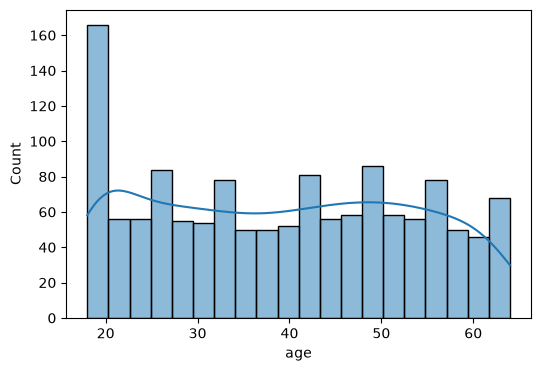

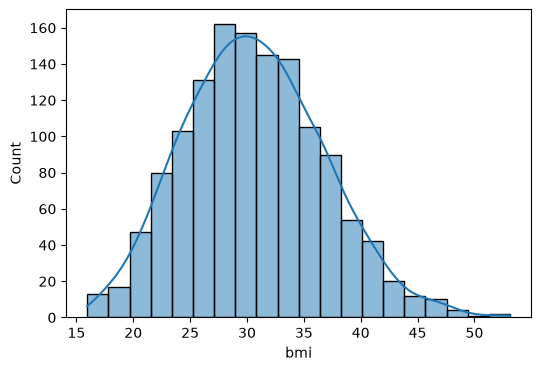

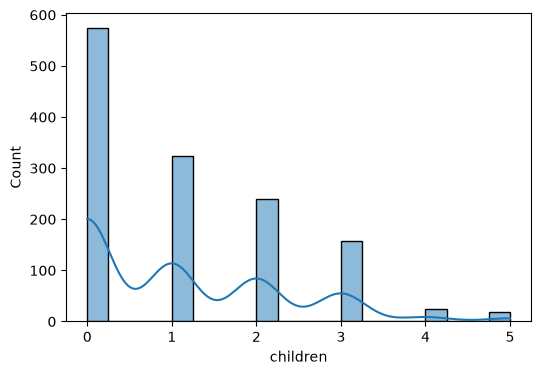

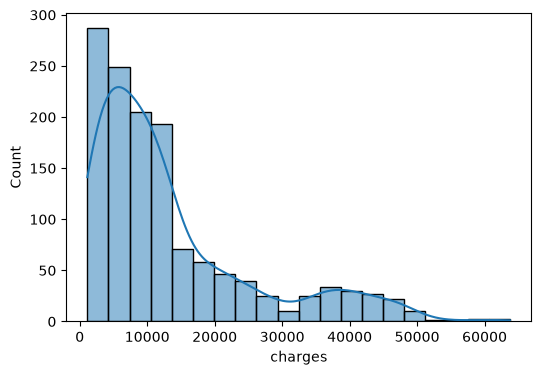

In [3]:
numerical_column = ('age','bmi','children','charges')

for col in numerical_column:
    plt.figure(figsize=(6,4))
    sc.histplot(df[col],kde=True, bins=20)

<Axes: xlabel='children', ylabel='count'>

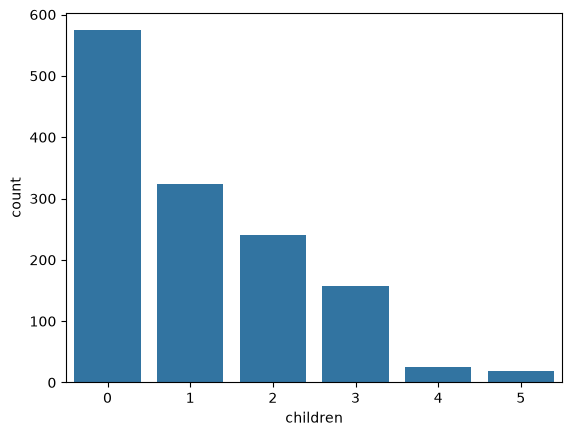

In [4]:
sc.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

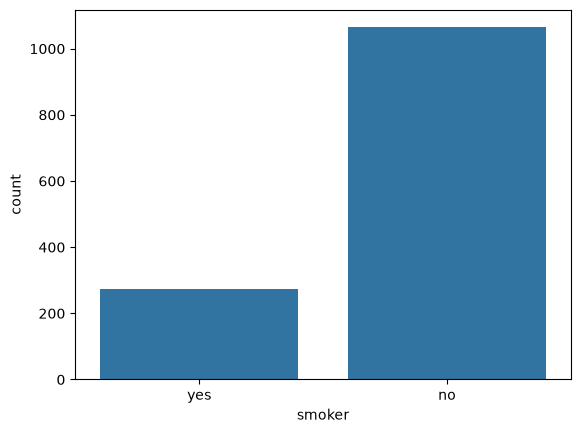

In [5]:
sc.countplot(x = df['smoker'])

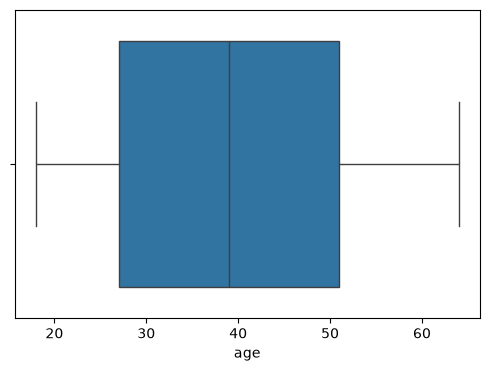

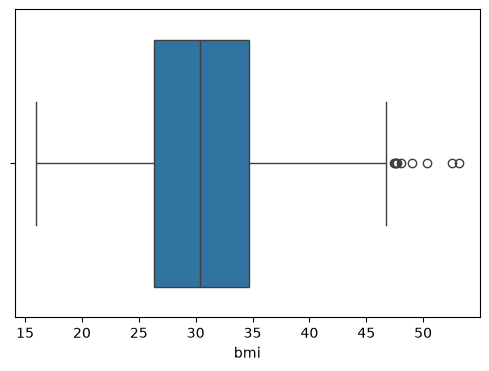

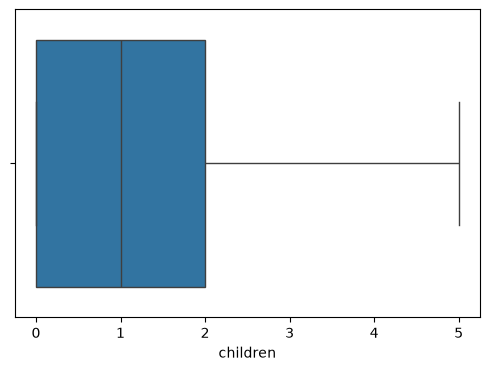

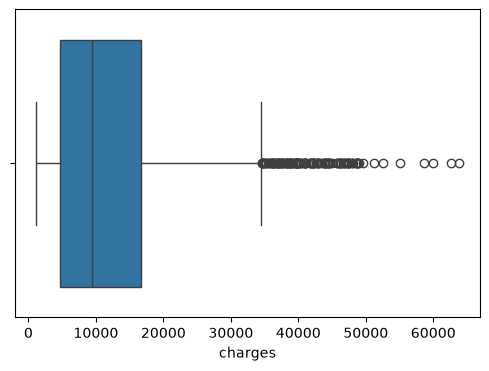

In [6]:
for col in numerical_column:
    plt.figure(figsize=(6,4))
    sc.boxplot(x= df[col])

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


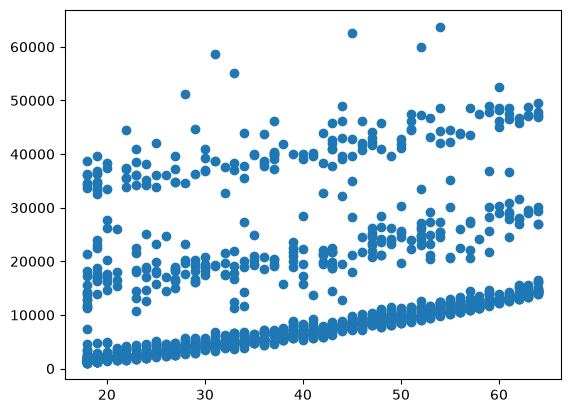

In [19]:
plt.scatter(df['age'],df['charges'])

In [ ]:
sc.heatmap(df.crr(numeric_only = True),annot=True)

# DATA CLEANING AND PREPROCESSING

In [8]:
df2 = df.copy()

In [9]:
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df2.shape


(1338, 7)

In [11]:
df2.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [12]:
df2.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df2.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [14]:
df2['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [ ]:
df2['sex'] = df2['sex'].map({"male": 0, "female" : 1})

In [ ]:
df2.head()

In [ ]:
df2['smoker'].value_counts()

In [ ]:
df2['smoker'] = df2['smoker'].map({"no" : 0, "yes": 1})

In [ ]:
df2.head()

In [ ]:
df2.rename(columns= {
    "sex" : "is_gender",
    "smoker" : "is_smoker"
}, inplace=True)

In [ ]:
df2.head()

In [ ]:
df2["region"].value_counts()

In [ ]:
df2 = pd.get_dummies(df2, columns=['region'],drop_first=True)


In [ ]:
df2 = df2.astype(int)

In [ ]:
df2

# FEATURE ENGINEERING & EXTRACTION

In [ ]:
sc.histplot(df['bmi'])

In [ ]:
df2['bmi_category'] = pd.cut(
    df2['bmi'],
    bins=[0, 18.5, 24.9,  29.9, float('inf')],
    labels=['underweight', 'normal','highweight','obese']
)

In [ ]:
df2

In [ ]:
df2 = pd.get_dummies(df2,columns=['bmi_category'],drop_first=True)

In [ ]:
df2 = df2.astype(int)

In [ ]:
df2

In [ ]:
df2.columns

In [ ]:
from sklearn.preprocessing import StandardScaler
col = ['age','bmi','children']
scaler = StandardScaler()

df2[col] = scaler.fit_transform(df2[col])

In [ ]:
df2.head()

In [ ]:
df2.columns

In [ ]:
from scipy.stats import pearsonr

#--------------------------------------
# PERSON CORRELATION CALCULATION
#--------------------------------------

# LIST OF FEATURE OF CHECK TO AGAINST TARGET

selected_feature = ['age', 'is_gender', 'bmi', 'children', 'is_smoker', 'charges','region_northwest', 'region_southeast', 'region_southwest',
'bmi_category_normal', 'bmi_category_highweight', 'bmi_category_obese']

correlations = {
    feature: pearsonr(df2[feature], df2['charges'])[0]
    for feature in selected_feature
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

In [ ]:
cat_features = [
    'is_gender',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_normal',
    'bmi_category_highweight',
    'bmi_category_obese'
]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df2['charges_bin'] = pd.qcut(df2['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df2[col], df2['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df



In [ ]:
final_df = df2[['age', 'is_gender', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_obese']]

In [ ]:
final_df

In [ ]:
df

In [ ]:
df2.dtypes


In [ ]:
df2

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = final_df.drop('charges', axis = 1)
y = final_df['charges']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)


In [ ]:
r2

In [ ]:
n = x_test.shape[0]
p = x_test.shape[1]
adjust_r2 = (1 -(1-r2) * (n-1) / (n - p -1))
adjust_r2

In [ ]:
final_df

In [ ]:
new_data = [[-1.4387, 1, -0.5181, 0.9086,1,0,0]]
# scaled = scaler.transform([[30,20,0]])

# new_data_selected = [[scaled[0][0],1,scaled[0][1],scaled[0][2],1,0,0]]

prediction = model.predict(new_data)

prediction

In [ ]:
r2_n = r2_score(y_test, prediction)
r2_n

In [ ]:
new_data = [[30, 1, 20, 3,0,1,0]]
scaled = scaler.transform([[30,20,0]])

new_data_selected = [[scaled[0][0],1,scaled[0][1],scaled[0][2],1,0,0]]

prediction = model.predict(new_data_selected)

prediction

In [ ]:
df

In [ ]:
new_data = [[19, 0, 28, 0,1,1,0]]
scaled = scaler.transform([[19,28,0]])

new_data_selected = [[scaled[0][0],1,scaled[0][1],scaled[0][2],1,0,0]]

prediction = model.predict(new_data_selected)

prediction

In [ ]:
error_per = abs(16844 - 25330) / 16844 * 100

In [ ]:
error_per